# Pillar 4 — Optimization: Why Plain Gradient Descent Struggles
## Demo 1: The Learning-Rate Problem

Same loss curve `L(w) = w²`, same starting point, three different learning rates.
This shows why hand-picking the learning rate (η) is fragile:
- **too small** → crawls, wastes time
- **just right** → smooth, fast descent
- **too big** → overshoots and diverges (loss explodes → "NaN" in real training)

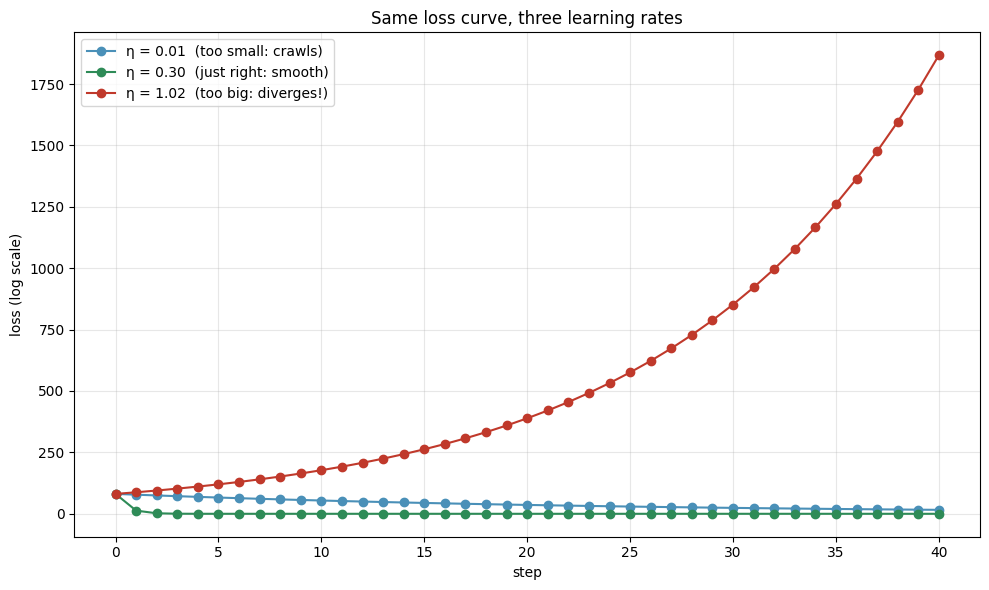

LOSS at selected steps (start loss = 81):
 step   too_small(0.01)  just_right(0.30)     too_big(1.02)
    0           81.0000         81.000000             81.00
    5           66.1829          0.008493            119.90
   10           54.0762          0.000001            177.48
   20           36.1017          0.000000            388.88
   40           16.0906          0.000000           1867.03


In [11]:
import matplotlib.pyplot as plt

def loss(w):
    return w**2

def gradient(w):
    return 2*w


def run_gd(learningRate,steps=40,w=9.0):
    history = []
    history.append(loss(w)) 
    for _ in range(steps): 
       w = w -learningRate * gradient(w)
       history.append(loss(w)) 
    return history    
        

too_small  = run_gd(0.01)   # crawls
just_right = run_gd(0.30)   # smooth descent
too_big    = run_gd(1.02)   # overshoots and diverges


plt.figure(figsize=(10,6))
plt.plot(too_small,  'o-', label='η = 0.01  (too small: crawls)',     color='#4a90b8')
plt.plot(just_right, 'o-', label='η = 0.30  (just right: smooth)',    color='#2e8b57')
plt.plot(too_big,    'o-', label='η = 1.02  (too big: diverges!)',    color='#c0392b')
# plt.yscale('log')                       # log scale so all three fit on one plot
plt.xlabel('step')
plt.ylabel('loss (log scale)')
plt.title('Same loss curve, three learning rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("LOSS at selected steps (start loss = 81):")
print(f"{'step':>5}{'too_small(0.01)':>18}{'just_right(0.30)':>18}{'too_big(1.02)':>18}")
for s in [0, 5, 10, 20, 40]:
    print(f"{s:>5}{too_small[s]:>18.4f}{just_right[s]:>18.6f}{too_big[s]:>18.2f}")
    

### What this shows
The learning rate is a razor's edge:
- **η=0.01** barely moves (81 → only 16 after 40 steps)
- **η=0.30** reaches ~0 in ~10 steps
- **η=1.02** *explodes* (81 → 1867 and climbing) — overshoots the bottom, bounces up the far wall

The "just right" window is **narrow and problem-specific** — you can't know it in advance.

## Demo 2: The Zigzag Problem (why Momentum exists)

Demo 1 used a simple *symmetric* bowl. Real loss surfaces are usually **stretched** —
much steeper in some directions than others. On these "narrow valleys," plain gradient
descent does something visibly wasteful: it **zigzags**.

Here the loss is an elongated bowl:

$$L(w_1, w_2) = w_1^2 + 20\,w_2^2$$

The ×20 makes the **w₂ direction 20× steeper** than w₁ — a long, narrow ravine.
We'll plot the *path* gradient descent takes on a contour map (top-down view) and watch
it bounce across the valley instead of heading straight to the minimum.

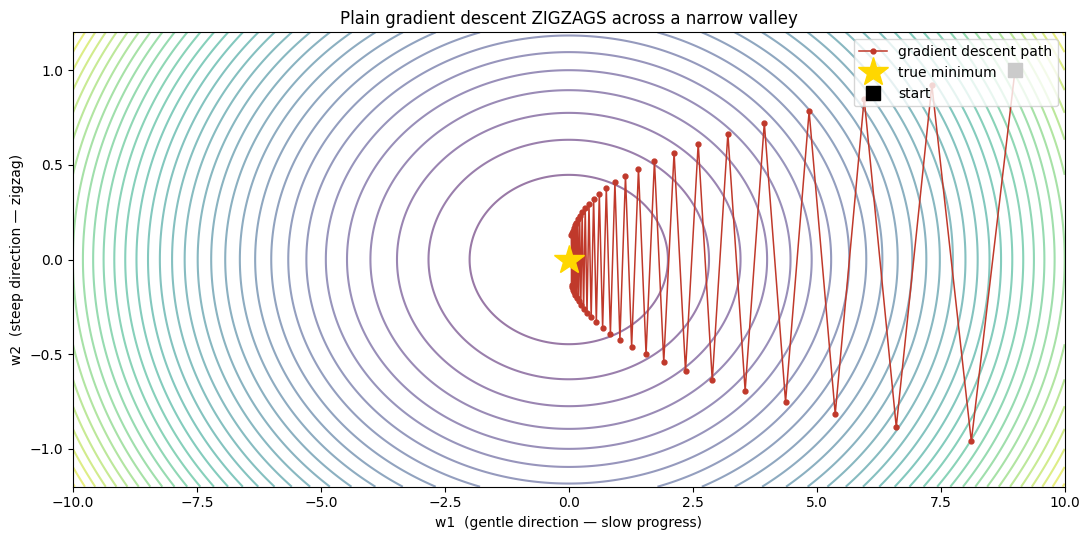

Watch w2 FLIP SIGN each step (zigzag) while w1 crawls:
 step          w1          w2        loss
    0      9.0000     1.00000    101.0000
    1      8.1180    -0.96000     84.3339
    2      7.3224     0.92160     70.6050
    3      6.6048    -0.88474     59.2790
    4      5.9576     0.84935     49.9204
    5      5.3737    -0.81537     42.1735
   10      3.2085     0.66483     19.1348
   20      1.1439     0.44200      5.2157
   50      0.0518     0.12989      0.3401


In [13]:


# Elongated bowl (narrow valley): steep in w2, gentle in w1
# L = w1^2 + 20*w2^2  ;  gradient = [2*w1, 40*w2]
def loss(w):     return w[0]**2 + 20*w[1]**2
def gradient(w): return np.array([2*w[0], 40*w[1]])

def run_gd(eta, steps=50, start=(9.0, 1.0)):
    w = np.array(start, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        w = w - eta * gradient(w)
        path.append(w.copy())
    return np.array(path)

# eta just below the steep direction's divergence threshold (2/40 = 0.05)
# -> w2 overshoots & flips sign each step (zigzag); w1 crawls
path = run_gd(eta=0.049, steps=50)

# contour map of the valley
w1 = np.linspace(-10, 10, 400)
w2 = np.linspace(-1.2, 1.2, 400)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 20*W2**2

plt.figure(figsize=(11, 5.5))
plt.contour(W1, W2, Z, levels=40, cmap='viridis', alpha=0.55)
plt.plot(path[:,0], path[:,1], 'o-', color='#c0392b', markersize=3.5,
         linewidth=1.1, label='gradient descent path')
plt.plot(0, 0, '*', color='gold', markersize=22, label='true minimum', zorder=5)
plt.plot(path[0,0], path[0,1], 's', color='black', markersize=10, label='start', zorder=5)
plt.xlabel('w1  (gentle direction — slow progress)')
plt.ylabel('w2  (steep direction — zigzag)')
plt.title('Plain gradient descent ZIGZAGS across a narrow valley')
plt.legend(loc='upper right'); plt.tight_layout()
plt.show()

# the numbers
print("Watch w2 FLIP SIGN each step (zigzag) while w1 crawls:")
print(f"{'step':>5}{'w1':>12}{'w2':>12}{'loss':>12}")
for s in [0,1,2,3,4,5,10,20,50]:
    print(f"{s:>5}{path[s,0]:>12.4f}{path[s,1]:>12.5f}{loss(path[s]):>12.4f}")

### What this shows

The **red path bounces across the valley** instead of going straight to the minimum (gold star):

- **w₂ flips sign every step** (+1.00 → −0.96 → +0.92 → −0.88 …) — the zigzag.
  It keeps overshooting the valley floor and landing on the opposite wall.
- **w₁ crawls** (9 → 8.1 → 7.3 …) — the direction that actually matters barely progresses.

**Why:** the gradient points in the *steepest* direction, which in a narrow valley is
mostly *across* the ravine (toward the near wall), **not** *along* it (toward the exit).
So each step lurches sideways and overshoots. The steepness **misleads** the descent.

**The trap:** no single learning rate fixes both directions —
- raise it → w₂ overshoots even harder (worse zigzag / diverges)
- lower it → w₁ crawls even slower

### The fixes this motivates
- **Momentum (item 3):** the flipping w₂ directions cancel out (+, −, +, − → ~0),
  while the consistent w₁ direction accumulates speed. Zigzag dies, real progress accelerates.
- **Adaptive rates (item 4):** give each direction its *own* learning rate, so w₁ and w₂
  aren't forced to share one.

## Demo 3: The Local-Minimum Problem (why non-convex landscapes are hard)

Demo 1 & 2 used **convex** losses — a single valley, so descent always finds the true bottom.
But real neural-net losses are **non-convex**: bumpy, with many dips. Gradient descent only
feels the slope *right where it stands*, so it can get **trapped in a shallow (local) minimum**
and never find the deep (global) one.

Here we run the **same algorithm with the same learning rate** from **two different starts**
and watch them end up in different minima.

[-14.         -13.99299825 -13.9859965  ...  13.9859965   13.99299825
  14.        ]
[29.92348161 29.8965358  29.86972598 ... 34.81270344 34.84466421
 34.87651839]


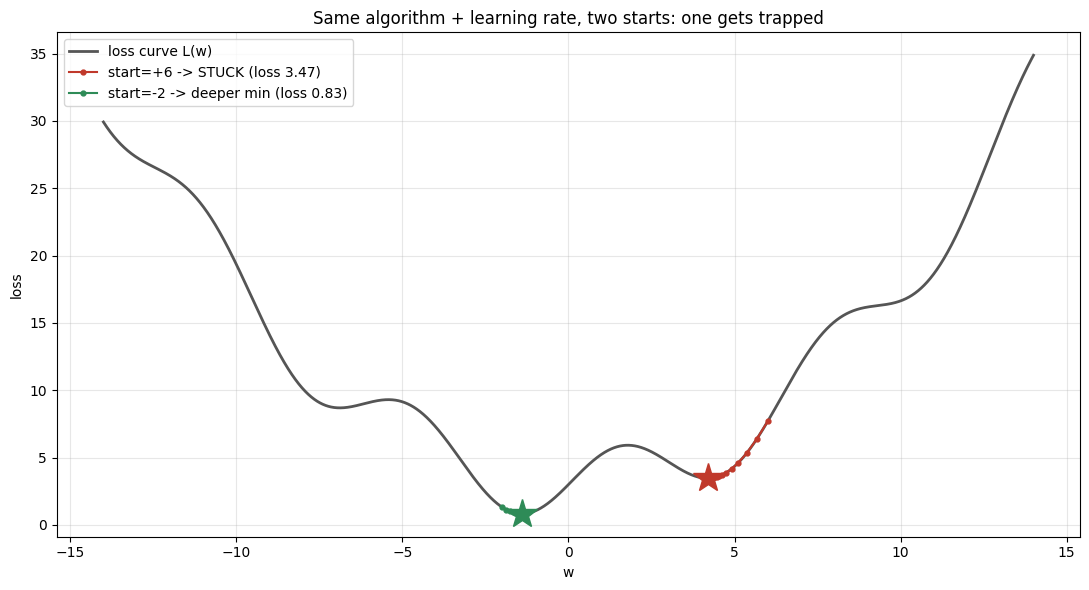

start +6 -> w=4.186, loss=3.467 (trapped, shallower)
start -2 -> w=-1.402, loss=0.830 (found deeper)
gradient at both ends ~0: 0.0001, -0.0000


In [21]:
def loss(w): 
    return 0.15*w**2 + 2.5*np.sin(w) + 3

def gradient(w):
  return  0.30*w + 2.5*np.cos(w)

def runGd(rate,w,steps=100):
    path = [w]
    for _ in range(steps):
        w = w - rate * gradient(w)
        path.append(w)
    return np.array(path) 

path_A = run_gd(eta=0.08, start=6.0)    # -> shallow local min (trapped)
path_B = run_gd(eta=0.08, start=-2.0)   # -> deeper min

w = np.linspace(-14, 14, 4000)
print(w)
L = loss(w)
print(L)


plt.figure(figsize=(11,6))
plt.plot(w, L, color='#555', linewidth=2, label='loss curve L(w)')
plt.plot(path_A, loss(path_A), 'o-', color='#c0392b', markersize=3.5,
         label=f'start=+6 -> STUCK (loss {loss(path_A[-1]):.2f})')
plt.plot(path_A[-1], loss(path_A[-1]), '*', color='#c0392b', markersize=22, zorder=6)
plt.plot(path_B, loss(path_B), 'o-', color='#2e8b57', markersize=3.5,
         label=f'start=-2 -> deeper min (loss {loss(path_B[-1]):.2f})')
plt.plot(path_B[-1], loss(path_B[-1]), '*', color='#2e8b57', markersize=22, zorder=6)
plt.xlabel('w'); plt.ylabel('loss')
plt.title('Same algorithm + learning rate, two starts: one gets trapped')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


print(f"start +6 -> w={path_A[-1]:.3f}, loss={loss(path_A[-1]):.3f} (trapped, shallower)")
print(f"start -2 -> w={path_B[-1]:.3f}, loss={loss(path_B[-1]):.3f} (found deeper)")
print(f"gradient at both ends ~0: {gradient(path_A[-1]):.4f}, {gradient(path_B[-1]):.4f}")